# MPC Multi-Horizon Experiment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from mpc_multi_horizon import (
    default_env_params,
    default_pop_params,
    extract_warm_start_action_history,
    load_warm_start_reference,
    run_single_horizon,
)

HORIZONS = [3, 5]
RAIN_START = 50
TOTAL_NUM_RAINFALLS = 50
PREVIEW_NUM_RAINFALLS = 3

RESULT_DIR = "results_mpc_horizons"
PREVIEW_RESULT_DIR = "results_mpc_horizons_preview"
PLOT_DIR = "results_mpc_horizons/plots"
PREVIEW_PLOT_PATH = "results_mpc_horizons_preview/preview_vs_single_step.png"

SINGLE_STEP_MPC_PATH = "results/MPC_GI.npy"
warm_start_path = "results/DQN3_GI.npy"

env_params = default_env_params()
pop_params = default_pop_params()

# Optional: reduce worker_count if the remote server has limited CPU or memory.
# pop_params["worker_count"] = 6
# pop_params["pop_size"] = 6

FULL_RAIN_IDS = list(range(RAIN_START, RAIN_START + TOTAL_NUM_RAINFALLS))
PREVIEW_RAIN_IDS = FULL_RAIN_IDS[:PREVIEW_NUM_RAINFALLS]
REMAINING_RAIN_IDS = FULL_RAIN_IDS[PREVIEW_NUM_RAINFALLS:]

print(env_params)
print(pop_params)
print("Preview rain IDs:", PREVIEW_RAIN_IDS)
print("Remaining rain IDs:", REMAINING_RAIN_IDS[:5], "... total", len(REMAINING_RAIN_IDS))
print("Warm start path:", warm_start_path)

{'orf': 'SWMM_GR\\chaohu_noHC', 'orf_save': 'chaohu_RTC', 'parm': 'states_yaml\\chaohu', 'advance_seconds': 300, 'kf': 1, 'kc': 1, 'reward_type': '3'}
{'pop_size': 10, 'max_value': 127, 'optstep': 150, 'simulation_steps': 95, 'worker_count': 10}
Preview rain IDs: [50, 51, 52]
Remaining rain IDs: [53, 54, 55, 56, 57] ... total 47
Warm start path: results/DQN3_GI.npy


C:\Users\tumbl\anaconda3\envs\drainage_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1. Validate warm start before any long run

In [2]:
def resolve_result_payload(record, rain_id):
    rainfall_key = f"rainfall{rain_id}"
    rainfall_data = record[rainfall_key]
    if "flooding" in rainfall_data and "CSO" in rainfall_data:
        return rainfall_data
    if "env3" in rainfall_data and isinstance(rainfall_data["env3"], dict):
        return rainfall_data["env3"]
    nested_candidates = [value for value in rainfall_data.values() if isinstance(value, dict) and "flooding" in value]
    if len(nested_candidates) == 1:
        return nested_candidates[0]
    raise KeyError(f"Unable to resolve payload for rainfall{rain_id}. Available keys: {list(rainfall_data.keys())}")

def flooding_plus_cso_series(record, rain_id):
    payload = resolve_result_payload(record, rain_id)
    flooding = np.asarray(payload["flooding"], dtype=float)[2:]
    cso = np.asarray(payload["CSO"], dtype=float)[2:]
    return flooding + cso

def reward_series(record, rain_id):
    payload = resolve_result_payload(record, rain_id)
    return np.asarray(payload["rewards"], dtype=float)

def validate_warm_start_file(path, rain_ids):
    warm_record = load_warm_start_reference(path)
    if warm_record is None:
        print("[WARNING] Warm start validation failed before MPC run.")
        return None, False

    warm_ok = True
    for rain_id in rain_ids:
        rainfall_key = f"rainfall{rain_id}"
        rainfall_data = warm_record.get(rainfall_key)
        if rainfall_data is None:
            print(f"[WARNING] Warm start missing rainfall key: {rainfall_key}")
            warm_ok = False
            continue

        action_history, source_key = extract_warm_start_action_history(rainfall_data)
        if not action_history:
            print(
                f"[WARNING] Warm start action history missing for {rainfall_key}. "
                f"Available keys: {list(rainfall_data.keys())}. Expected rainfall->env3->action or rainfall->action."
            )
            warm_ok = False
        else:
            print(
                f"[INFO] Warm start validated for {rainfall_key}: source={source_key}, "
                f"action_length={len(action_history)}"
            )
    return warm_record, warm_ok

warm_start_reference, warm_start_ok = validate_warm_start_file(warm_start_path, PREVIEW_RAIN_IDS)
print("Warm start ready:", warm_start_ok)

[INFO] Warm start file loaded: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\DQN3_GI.npy
[INFO] Warm start validated for rainfall50: source=env3, action_length=95
[INFO] Warm start validated for rainfall51: source=env3, action_length=95
[INFO] Warm start validated for rainfall52: source=env3, action_length=95
Warm start ready: True


## Step 2. Run only the first few rainfalls for quick preview

This step only runs rainfalls corresponding to `PREVIEW_RAIN_IDS` to quickly assess whether `h=3` and `h=5` are worth running for the full dataset.

In [3]:
assert warm_start_ok, "Warm start validation failed. Read the warning above before running multi-step MPC."

preview_results = {}
for horizon in HORIZONS:
    preview_path = Path(PREVIEW_RESULT_DIR) / f"MPC_GI_h{horizon}_preview.npy"
    preview_results[horizon] = run_single_horizon(
        prediction_horizon=horizon,
        rain_ids=PREVIEW_RAIN_IDS,
        result_path=preview_path,
        env_params=env_params,
        pop_params=pop_params,
        warm_start_path=warm_start_path,
    )

sorted(preview_results.keys())

[INFO] Warm start file loaded: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\DQN3_GI.npy
Running MPC for rainfall 50 with horizon=3
[INFO] Warm start is active for rainfall 50 from results/DQN3_GI.npy using source 'env3'.
duration: 482.306 s
Running MPC for rainfall 51 with horizon=3
[INFO] Warm start is active for rainfall 51 from results/DQN3_GI.npy using source 'env3'.


C:\Users\tumbl\anaconda3\envs\drainage_new\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


duration: 505.729 s
Running MPC for rainfall 52 with horizon=3
[INFO] Warm start is active for rainfall 52 from results/DQN3_GI.npy using source 'env3'.
duration: 459.553 s
Saved horizon=3 results to: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_mpc_horizons_preview\MPC_GI_h3_preview.npy
[INFO] Warm start file loaded: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\DQN3_GI.npy
Running MPC for rainfall 50 with horizon=5
[INFO] Warm start is active for rainfall 50 from results/DQN3_GI.npy using source 'env3'.


C:\Users\tumbl\anaconda3\envs\drainage_new\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


duration: 688.686 s
Running MPC for rainfall 51 with horizon=5
[INFO] Warm start is active for rainfall 51 from results/DQN3_GI.npy using source 'env3'.
duration: 697.048 s
Running MPC for rainfall 52 with horizon=5
[INFO] Warm start is active for rainfall 52 from results/DQN3_GI.npy using source 'env3'.
duration: 674.908 s
Saved horizon=5 results to: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_mpc_horizons_preview\MPC_GI_h5_preview.npy


[3, 5]

## Step 3. Compare preview results with the original single-step MPC

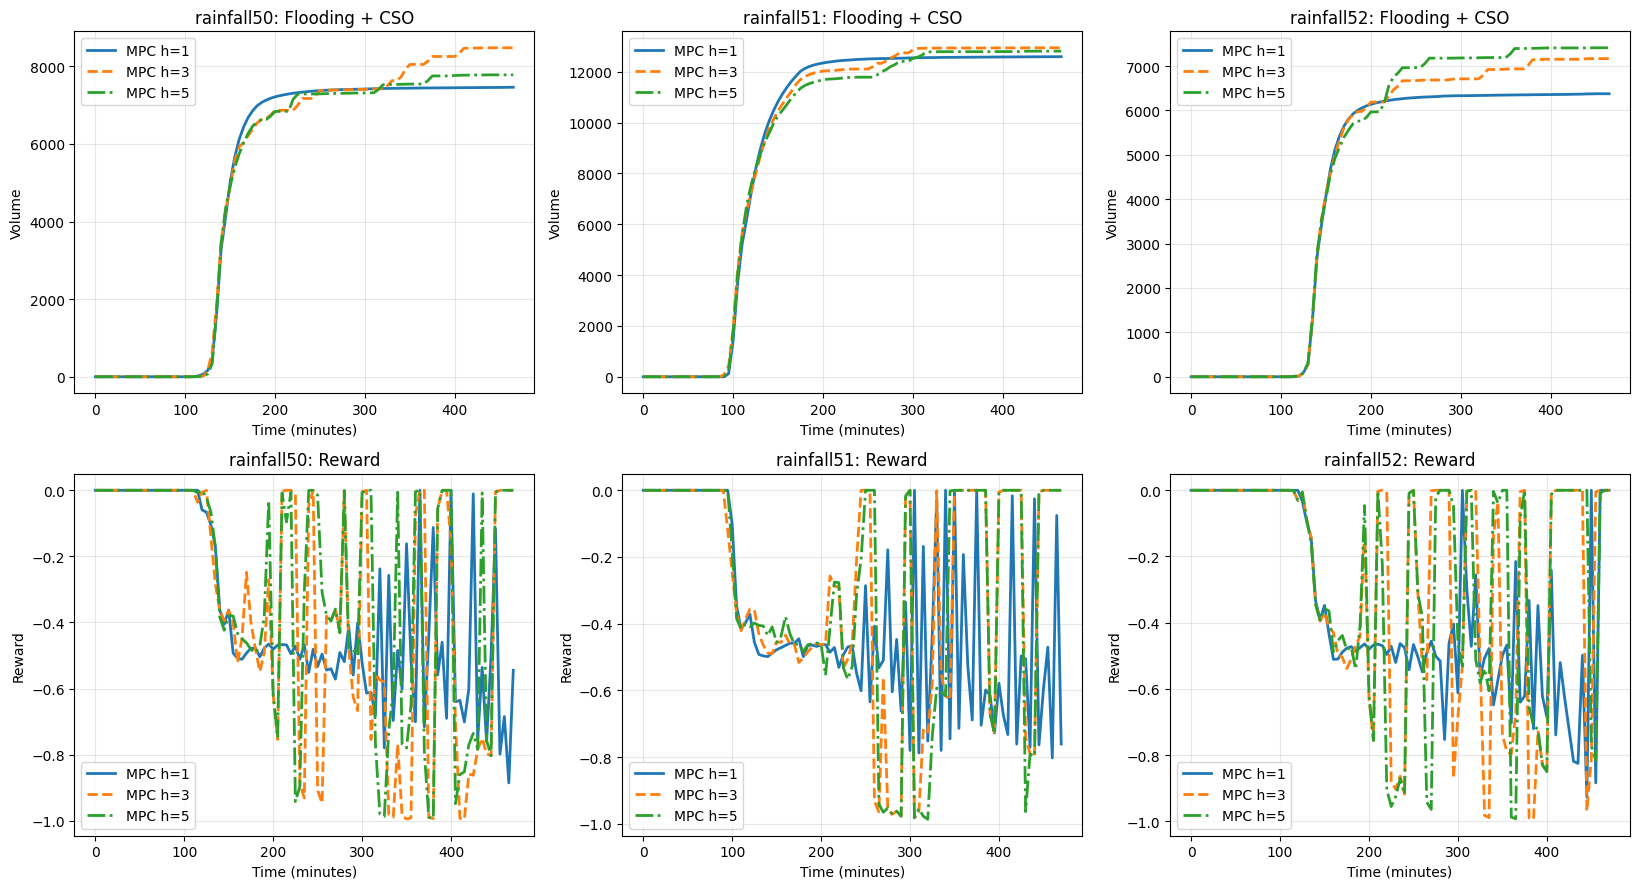

Saved preview comparison figure to: results_mpc_horizons_preview\preview_vs_single_step.png


In [4]:
single_step_record = np.load(SINGLE_STEP_MPC_PATH, allow_pickle=True).tolist()

n_preview = len(PREVIEW_RAIN_IDS)
fig, axes = plt.subplots(2, n_preview, figsize=(5.5 * n_preview, 9), squeeze=False)

for col, rain_id in enumerate(PREVIEW_RAIN_IDS):
    flood_ax = axes[0, col]
    reward_ax = axes[1, col]

    single_fc = flooding_plus_cso_series(single_step_record, rain_id)
    single_reward = reward_series(single_step_record, rain_id)
    time_single = np.arange(len(single_fc)) * env_params["advance_seconds"] / 60.0
    reward_time_single = np.arange(len(single_reward)) * env_params["advance_seconds"] / 60.0

    flood_ax.plot(time_single, single_fc, label="MPC h=1", linewidth=2.0, color="#1f77b4")
    reward_ax.plot(reward_time_single, single_reward, label="MPC h=1", linewidth=2.0, color="#1f77b4")

    for horizon, color, linestyle in [(3, "#ff7f0e", "--"), (5, "#2ca02c", "-.")]:
        preview_record = preview_results[horizon]
        fc = flooding_plus_cso_series(preview_record, rain_id)
        rw = reward_series(preview_record, rain_id)
        time_fc = np.arange(len(fc)) * env_params["advance_seconds"] / 60.0
        time_rw = np.arange(len(rw)) * env_params["advance_seconds"] / 60.0
        flood_ax.plot(time_fc, fc, label=f"MPC h={horizon}", linewidth=2.0, color=color, linestyle=linestyle)
        reward_ax.plot(time_rw, rw, label=f"MPC h={horizon}", linewidth=2.0, color=color, linestyle=linestyle)

    flood_ax.set_title(f"rainfall{rain_id}: Flooding + CSO")
    flood_ax.set_xlabel("Time (minutes)")
    flood_ax.set_ylabel("Volume")
    flood_ax.grid(True, alpha=0.3)
    flood_ax.legend()

    reward_ax.set_title(f"rainfall{rain_id}: Reward")
    reward_ax.set_xlabel("Time (minutes)")
    reward_ax.set_ylabel("Reward")
    reward_ax.grid(True, alpha=0.3)
    reward_ax.legend()

plt.tight_layout()
preview_plot_path = Path(PREVIEW_PLOT_PATH)
preview_plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(preview_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved preview comparison figure to:", preview_plot_path)

## Step 4. Continue the remaining rainfalls only if the preview looks good

This cell will only run `REMAINING_RAIN_IDS`, then merge the preview and remaining results and save the final full dataset:

- `results_mpc_horizons/MPC_GI_h3_all_rainfalls.npy`
- `results_mpc_horizons/MPC_GI_h5_all_rainfalls.npy`

In [ ]:
assert warm_start_ok, "Warm start validation failed. Fix the warning above before running the remaining rainfalls."

remaining_results = {}
full_results = {}

for horizon in HORIZONS:
    remaining_path = Path(PREVIEW_RESULT_DIR) / f"MPC_GI_h{horizon}_remaining.npy"
    remaining_results[horizon] = run_single_horizon(
        prediction_horizon=horizon,
        rain_ids=REMAINING_RAIN_IDS,
        result_path=remaining_path,
        env_params=env_params,
        pop_params=pop_params,
        warm_start_path=warm_start_path,
    )

    if "preview_results" in globals() and horizon in preview_results:
        preview_data = preview_results[horizon]
    else:
        preview_data = np.load(Path(PREVIEW_RESULT_DIR) / f"MPC_GI_h{horizon}_preview.npy", allow_pickle=True).tolist()

    merged = dict(preview_data)
    merged.update(remaining_results[horizon])
    full_results[horizon] = merged

    final_path = Path(RESULT_DIR) / f"MPC_GI_h{horizon}_all_rainfalls.npy"
    final_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(final_path, merged)
    print(f"Saved full horizon={horizon} results to: {final_path} (rainfalls={len(merged)})")

sorted(full_results.keys())

## Real Rainfall x5: Multi-Horizon MPC (h=3, h=5)

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from mpc_multi_horizon import (
    default_env_params,
    default_pop_params,
    ensure_temp_dirs,
    load_context,
    load_warm_start_reference,
    extract_warm_start_action_history,
    MPCExperiment,
)

REAL_HORIZONS = [3, 5]
REAL_RESULT_DIR = Path("results_m_real_mpc_horizons")
REAL_PLOT_DIR = REAL_RESULT_DIR / "plots"

REAL_SINGLE_STEP_PATH = Path("results_m_real/MPC_GI.npy")

REAL_WARM_START_PATH = "results_m_real/DQN3_GI.npy"

real_raindata = np.load("rainfall/real_raindata.npy", allow_pickle=True).tolist()
real_raindata = [
    [
        [time, str(float(rain) * 5.0)]
        for time, rain in event
    ]
    for event in real_raindata
]

REAL_RAIN_IDS = list(range(len(real_raindata)))

real_env_params = default_env_params()
real_pop_params = default_pop_params()

# real_pop_params["worker_count"] = 6
# real_pop_params["pop_size"] = 10
# real_pop_params["optstep"] = 150

real_env_params, real_config, real_action_table, _ = load_context(real_env_params)
ensure_temp_dirs(REAL_RAIN_IDS)

print("Real rainfall count:", len(real_raindata))
print("Real rainfall IDs:", REAL_RAIN_IDS)
print("Real warm start path:", REAL_WARM_START_PATH)
print("Single-step real MPC path exists:", REAL_SINGLE_STEP_PATH.exists())
print(real_env_params)
print(real_pop_params)

def validate_real_warm_start(path, rain_ids):
    warm_record = load_warm_start_reference(path)
    if warm_record is None:
        print("[WARNING] Real-rainfall warm start validation failed before MPC run.")
        return None, False

    warm_ok = True
    for rain_id in rain_ids:
        rainfall_key = f"rainfall{rain_id}"
        rainfall_data = warm_record.get(rainfall_key)

        if rainfall_data is None:
            print(f"[WARNING] Warm start missing rainfall key: {rainfall_key}")
            warm_ok = False
            continue

        action_history, source_key = extract_warm_start_action_history(rainfall_data)
        if not action_history:
            available_keys = list(rainfall_data.keys()) if isinstance(rainfall_data, dict) else []
            print(
                f"[WARNING] Warm start action history missing for {rainfall_key}. "
                f"Available keys: {available_keys}"
            )
            warm_ok = False
        else:
            print(
                f"[INFO] Warm start validated for {rainfall_key}: "
                f"source={source_key}, action_length={len(action_history)}"
            )

    return warm_record, warm_ok

real_warm_start_reference, real_warm_start_ok = validate_real_warm_start(
    REAL_WARM_START_PATH,
    REAL_RAIN_IDS,
)

print("Real rainfall warm start ready:", real_warm_start_ok)

Real rainfall count: 4
Real rainfall IDs: [0, 1, 2, 3]
Real warm start path: results_m_real/DQN3_GI.npy
Single-step real MPC path exists: True
{'orf': 'SWMM_GR\\chaohu_noHC', 'orf_save': 'chaohu_RTC', 'parm': 'states_yaml\\chaohu', 'advance_seconds': 300, 'kf': 1, 'kc': 1, 'reward_type': '3'}
{'pop_size': 10, 'max_value': 127, 'optstep': 150, 'simulation_steps': 95, 'worker_count': 10}
[INFO] Warm start file loaded: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_m_real\DQN3_GI.npy
[INFO] Warm start validated for rainfall0: source=env3, action_length=95
[INFO] Warm start validated for rainfall1: source=env3, action_length=95
[INFO] Warm start validated for rainfall2: source=env3, action_length=95
[INFO] Warm start validated for rainfall3: source=env3, action_length=95
Real rainfall warm start ready: True


In [4]:
assert real_warm_start_ok, "Real-rainfall warm start validation failed. Fix the warning above before running h=3/h=5 MPC."

real_multi_results = {}

for horizon in REAL_HORIZONS:
    print("=" * 80)
    print(f"Running real rainfalls with prediction horizon = {horizon}")
    print("=" * 80)

    horizon_results = {}
    for rain_id in REAL_RAIN_IDS:
        print(f"Running real rainfall {rain_id} with horizon={horizon}")

        experiment = MPCExperiment(
            rain_id=rain_id,
            rainfall_timeseries=real_raindata[rain_id],
            prediction_horizon=horizon,
            env_params=real_env_params,
            pop_params=real_pop_params,
            config=real_config,
            action_table=real_action_table,
            warm_start_reference=real_warm_start_reference,
            warm_start_path=REAL_WARM_START_PATH,
        )

        horizon_results[f"rainfall{rain_id}"] = experiment.run()

    save_path = REAL_RESULT_DIR / f"MPC_GI_real_h{horizon}.npy"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(save_path, horizon_results)
    print(f"Saved real-rainfall horizon={horizon} results to: {save_path}")

    real_multi_results[horizon] = horizon_results

sorted(real_multi_results.keys())

Running real rainfalls with prediction horizon = 3
Running real rainfall 0 with horizon=3
[INFO] Warm start is active for rainfall 0 from results_m_real/DQN3_GI.npy using source 'env3'.
Running real rainfall 1 with horizon=3
[INFO] Warm start is active for rainfall 1 from results_m_real/DQN3_GI.npy using source 'env3'.
Running real rainfall 2 with horizon=3
[INFO] Warm start is active for rainfall 2 from results_m_real/DQN3_GI.npy using source 'env3'.


C:\Users\tumbl\anaconda3\envs\drainage_new\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Running real rainfall 3 with horizon=3
[INFO] Warm start is active for rainfall 3 from results_m_real/DQN3_GI.npy using source 'env3'.
Saved real-rainfall horizon=3 results to: results_m_real_mpc_horizons\MPC_GI_real_h3.npy
Running real rainfalls with prediction horizon = 5
Running real rainfall 0 with horizon=5
[INFO] Warm start is active for rainfall 0 from results_m_real/DQN3_GI.npy using source 'env3'.
Running real rainfall 1 with horizon=5
[INFO] Warm start is active for rainfall 1 from results_m_real/DQN3_GI.npy using source 'env3'.
Running real rainfall 2 with horizon=5
[INFO] Warm start is active for rainfall 2 from results_m_real/DQN3_GI.npy using source 'env3'.
Running real rainfall 3 with horizon=5
[INFO] Warm start is active for rainfall 3 from results_m_real/DQN3_GI.npy using source 'env3'.
Saved real-rainfall horizon=5 results to: results_m_real_mpc_horizons\MPC_GI_real_h5.npy


[3, 5]